# What Makes a Hit Song?

Goal:
Identify patterns in Spotify tracks and explore what defines popular songs

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [18]:
df = pd.read_csv("../data/spotify.csv")

df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

# Data cleaning:

In [19]:
# Ta bort irrelevanta kolumner
df = df.drop(columns=["track_id", "track_name", "artists", "album_name"])

# Ta bort saknade värden
df = df.dropna()

df.shape

(114000, 17)

# Chosing features:

In [20]:
features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo"
]

X = df[features]

# EDA:

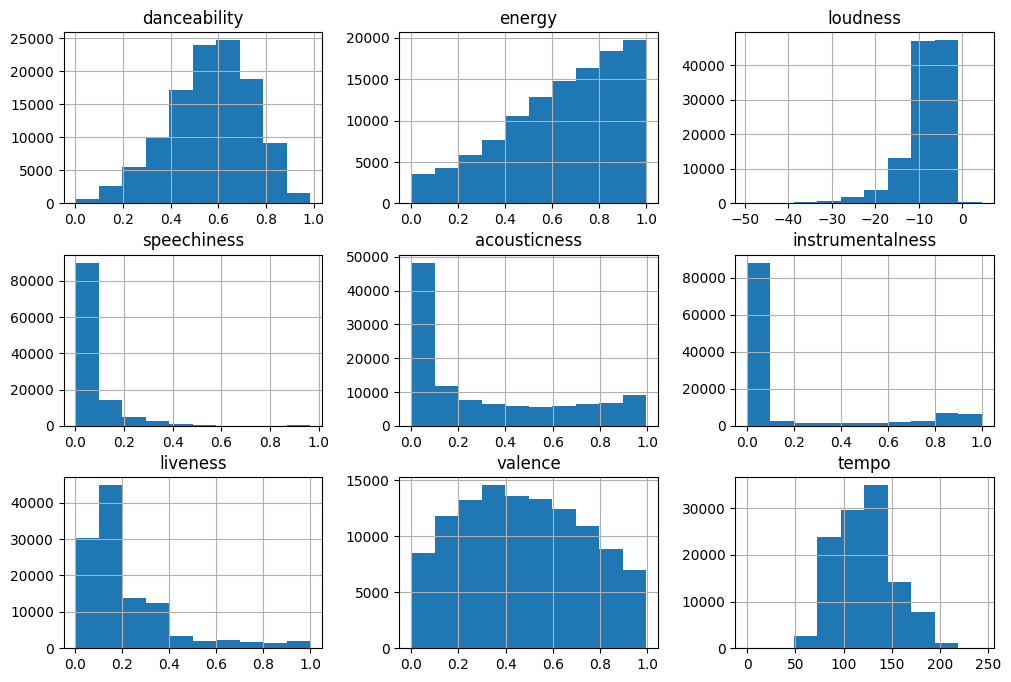

In [21]:
X.hist(figsize=(12,8))
plt.show()

# Correlation heatmap:

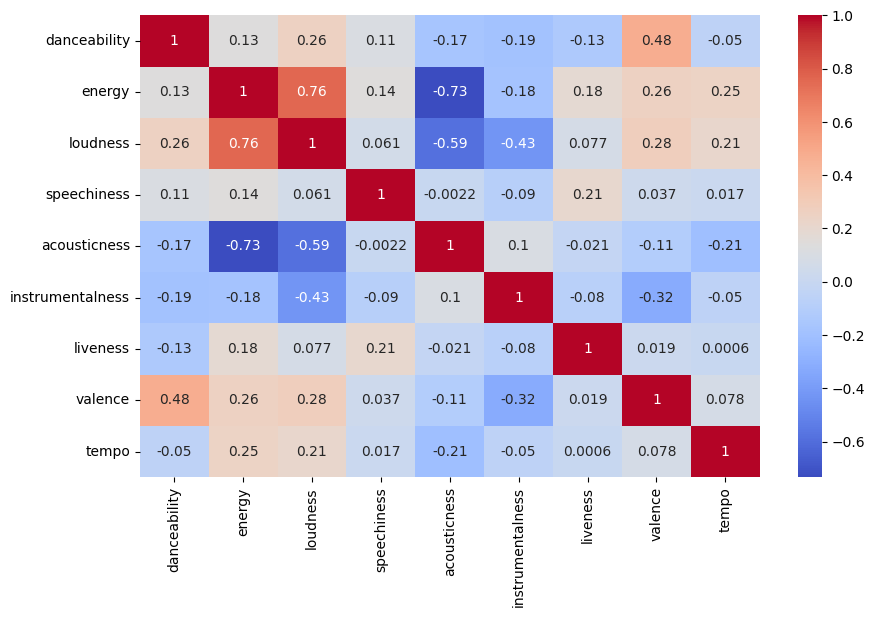

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.show()

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA - visualizing:

In [24]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA:

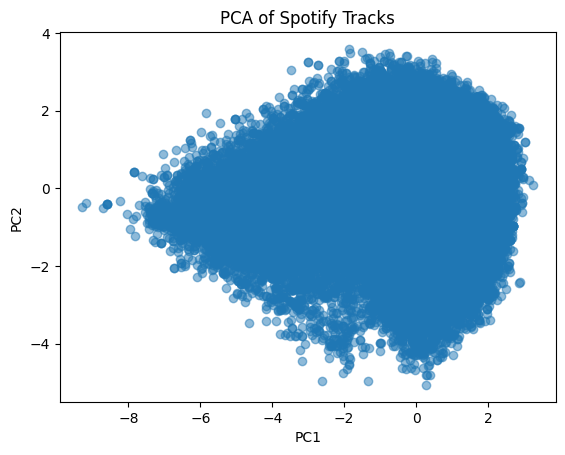

In [25]:
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title("PCA of Spotify Tracks")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# KMeans (cluster):

In [26]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

# Cluster - visualized:

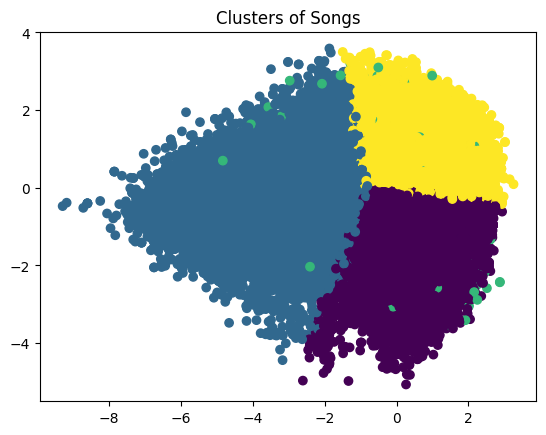

In [27]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis")
plt.title("Clusters of Songs")
plt.show()

# Avarage value per cluster:

In [28]:
cluster_summary = df.groupby("cluster")[features].mean()
cluster_summary

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.477739,0.807085,-5.965387,0.080056,0.087310,0.192692,0.266178,0.339961,136.277016
1,0.456130,0.281554,-14.645326,0.050347,0.764975,0.320810,0.172370,0.291373,109.820734
2,0.585916,0.659547,-10.444516,0.736812,0.650575,0.016638,0.568844,0.464178,105.924125
3,0.686069,0.690610,-6.827927,0.085360,0.257939,0.053389,0.183628,0.662542,118.022016


# Interpretation

Cluster 0 – “High Energy / Party-ish”

Keyvalues:

Energy: high (0.80)
Loudness: loud (-5.9 = ganska högt)
Tempo: fast (136 BPM)
Acousticness: low

= Intense, fast, electronic songs

Description:
“High-energy party tracks”

Ex:
EDM
Dance
Gym-music

# Hit-analysis
-What type of songs become hit songs?

In [29]:
df.groupby("cluster")["popularity"].mean()

cluster
0    34.374267
1    31.374081
2    27.120724
3    33.470179
Name: popularity, dtype: float64

# = Highest cluster is 0:

Hits are:

- energetic
- fast
- intense

# DBSCAN - outliers:

In [30]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Conclusion:

We identified four distinct types of songs: high-energy tracks, acoustic songs, speech-heavy tracks and mainstream pop.

When comparing popularity, we found that the high-energy cluster had the highest average popularity.

This suggests that energetic, loud and fast-paced characteristics are more likely to be associated with hit songs.